# Other earth processes modelling

The goal here is to replicate other non-wave geomagnetic signals as a background for the synthetics.

This is different from covariance, it is not uncertainty based, but instead trying to replicate the effects of other genuine signal.

THIS IS A STRETCH GOAL.

rough plan:

- want to generate coloured noise at each coefficient (n<=15)
- therefore get CHAOS gauss coefficient time series
- DO NOT WEIGHT/ LOWES SCALE - no need, adds unecessary complication
- instead just get spectrum for each coefficient, fit AR-1 process to it
- in theory should get a signal that satisfies CHAOS (broadly) and adds realistic disturbance

only do this if you somehow have lots of time

In [2]:
# setting up file path for imports
import sys
import os
from pathlib import Path

cwd = Path(os.getcwd())
print(cwd)
PROJECT_ROOT = cwd.resolve().parents[2]
sys.path.insert(0, str(PROJECT_ROOT))

# installing relevant libraries
import chaosmagpy as cp
import numpy as np
import matplotlib.pyplot as plt
import h5py

# Project paths / utilities
from src.msc_thesis.paths import *
from src.msc_thesis.synSetup import *
from src.msc_thesis.synUtils import *
from src.msc_thesis.synDMD import *

/home/elliott/projects/msc_thesis_project/Last_stretch/Data_prep/Non_signal_Data
['/home/elliott/projects/msc_thesis_project', '/home/elliott/miniforge3/envs/msc_thesis/lib/python311.zip', '/home/elliott/miniforge3/envs/msc_thesis/lib/python3.11', '/home/elliott/miniforge3/envs/msc_thesis/lib/python3.11/lib-dynload', '', '/home/elliott/miniforge3/envs/msc_thesis/lib/python3.11/site-packages', '/home/elliott/projects/msc_thesis_project']
['/home/elliott/projects/msc_thesis_project', '/home/elliott/projects/msc_thesis_project', '/home/elliott/miniforge3/envs/msc_thesis/lib/python311.zip', '/home/elliott/miniforge3/envs/msc_thesis/lib/python3.11', '/home/elliott/miniforge3/envs/msc_thesis/lib/python3.11/lib-dynload', '', '/home/elliott/miniforge3/envs/msc_thesis/lib/python3.11/site-packages', '/home/elliott/projects/msc_thesis_project']


/home/elliott/miniforge3/envs/msc_thesis/lib/python3.11/site-packages/chaosmagpy/model_utils.py:795: UserWarning: Input coordinates include the poles.
  warnings.warn('Input coordinates include the poles.')


['/home/elliott/projects/msc_thesis_project', '/home/elliott/projects/msc_thesis_project', '/home/elliott/projects/msc_thesis_project', '/home/elliott/miniforge3/envs/msc_thesis/lib/python311.zip', '/home/elliott/miniforge3/envs/msc_thesis/lib/python3.11', '/home/elliott/miniforge3/envs/msc_thesis/lib/python3.11/lib-dynload', '', '/home/elliott/miniforge3/envs/msc_thesis/lib/python3.11/site-packages', '/home/elliott/projects/msc_thesis_project']
C has shape dimensions: (148, 440, 440)


In [5]:
# CHAOS gauss coeffs
gnm_chaos_full = CHAOS_Full_SV_Record_Obtain()

# applying just to ideal synthetic record - equivalent to others
gnm_chaos = Gauss_Record_Prepare(gnm_chaos_full, tmax=15)

# Synthetic gauss coeffs
mode_numbers = np.arange(1, 63, 10)
mode_numbers = [str(mode_number) for mode_number in mode_numbers]
gnm_syn_ideal_full, gnm_syn_full, syn_suite_info = Synthetic_Full_SV_Record_Obtain(mode_numbers, times_res_relative)

# applying just to ideal synthetic record - equivalent to others
gnm_syn = Gauss_Record_Prepare(gnm_syn_full, tmax=15)



Full CHAOS-8.6 timespan is: [1997.1 2026.6]


Loading combined modes: 100%|██████████| 7/7 [00:00<00:00, 62.32it/s]


In [6]:
# have relevant record of chaos gauss coefficients
Nt, Ng = np.shape(gnm_chaos)

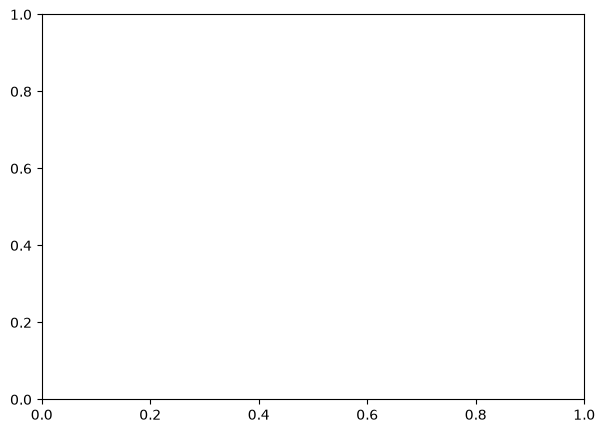

In [ ]:

from scipy.signal import firwin2, lfilter

def Non_Wave_Spectral_Infill(gnm_chaos, gnm_syn, dt_sample=dt_sample):

    f_sample = 1/dt_sample

    seed = 42

    g_noise_empty = np.zeros_like(gnm_chaos)

    rng = np.random.default_rng(seed)

    for g_idx in range(Ng):

        g_series_chaos = gnm_chaos[:, g_idx]
        g_series_mode = gnm_syn[:, g_idx]

        g_f_c, g_p_c = periodogram(
            g_series_chaos,
            fs=f_sample,
            detrend=None,
        )

        _, g_p_m = periodogram(
            g_series_mode,
            fs=f_sample,
            detrend=None,
        )

        g_p_diff = np.maximum(g_p_c - g_p_m, 0)

        frequencies = g_f_c.copy()
        amp_gains = np.sqrt(g_p_diff)

        f_nyquist = f_sample / 2

        if frequencies[-1] < f_nyquist:
            frequencies = np.append(frequencies, f_nyquist)
            amp_gains = np.append(amp_gains, amp_gains[-1])

        taps = firwin2(
            numtaps=101,
            freq=frequencies,
            gain=amp_gains,
            fs=f_sample,
        )

        burn_in = 3 * 101
        white = rng.normal(size=Nt + burn_in)
        noise = lfilter(taps, 1.0, white)[burn_in:]

        g_noise_empty[:, g_idx] = noise




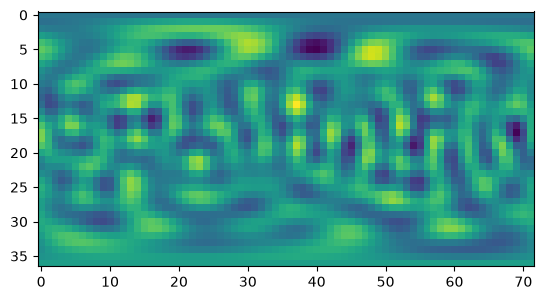

In [25]:
plt.imshow(np.reshape(A_15_r @ Truncate_Gauss_Coeffs(g_noise_empty[0,:], tmax=15).T,shape=state_shape))

In [26]:
video_noise_sv = A_15_r @ Truncate_Gauss_Coeffs(g_noise_empty, tmax=15).T

In [28]:
Cube_Movie(A_15_r @ Truncate_Gauss_Coeffs(gnm_chaos, tmax=15).T)

'/home/elliott/projects/msc_thesis_project/figures/data_cube.mp4'

In [ ]:

from scipy.signal import firwin2, lfilter

def broken_powerlaw_noise(
    nt,
    dt,
    f_corner,
    slope=-2.0,
    seed=None,
    numtaps=201,
):
    """
    Generate unit-variance coloured noise with theoretical PSD:

        P(f) = constant                    for f <= f_corner
        P(f) ∝ f**slope                   for f > f_corner

    Frequencies are in cycles per unit time.
    """

    rng = np.random.default_rng(seed)
    fs = f_sample
    f_nyquist = fs / 2.0

    if not 0 < f_corner < f_nyquist:
        raise ValueError("f_corner must lie between 0 and the Nyquist frequency.")

    # Dense frequency grid describing a continuous filter response
    f = np.linspace(0.0, f_nyquist, 2048)

    # Desired power spectrum
    power = np.ones_like(f)
    high_f = f > f_corner
    power[high_f] = (f[high_f] / f_corner) ** slope

    # Filter amplitude squared gives the output power
    amplitude = np.sqrt(power)

    taps = firwin2(
        numtaps,
        f / f_nyquist,
        amplitude,
    )

    # Generate extra noise and remove the initial filter transient
    burn_in = 3 * numtaps
    white = rng.normal(size=nt + burn_in)
    coloured = lfilter(taps, 1.0, white)[burn_in:]

    coloured -= coloured.mean()
    coloured /= coloured.std()

    return coloured

/tmp/ipykernel_3196/2897894753.py:28: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


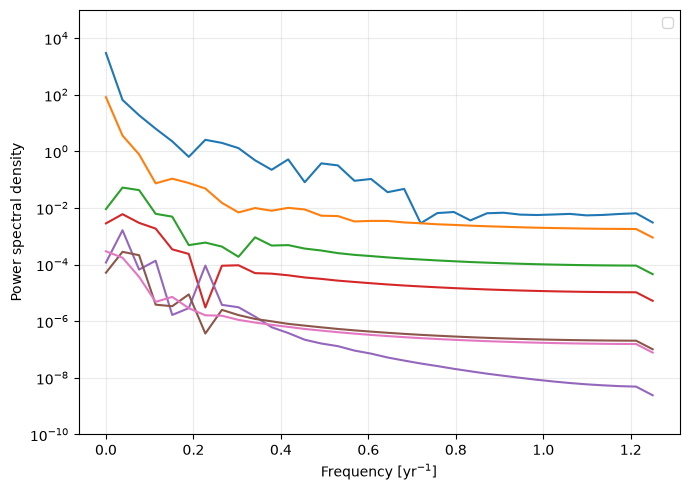

In [ ]:

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import periodogram

fig, ax = plt.subplots(figsize=(7, 5))


# Multiple runs
for g_idx in range(0, Ng, 40):
    g_series = gnm_chaos[:, g_idx]
    g_f, g_p = periodogram(g_series, fs=f_sample, detrend=None)

    ax.semilogy(
        g_f,
        g_p,
    )



ax.set(
    xlabel="Frequency [yr$^{-1}$]",
    ylabel="Power spectral density",
)

ax.set_ylim(1e-10, 1e5)
ax.legend()
ax.grid(True, which="both", alpha=0.25)
fig.tight_layout()
plt.show()

In [8]:
f_sample = 1/dt_sample

seed = 42

chaos_psd = []

rng = np.random.default_rng(seed)

for g_idx in range(Ng):

    g_series_chaos = gnm_chaos[:, g_idx]
    g_series_mode = gnm_syn[:, g_idx]

    g_f_c, g_p_c = periodogram(
        g_series_chaos,
        fs=f_sample,
        detrend=None,
    )

    chaos_psd.append(g_p_c)

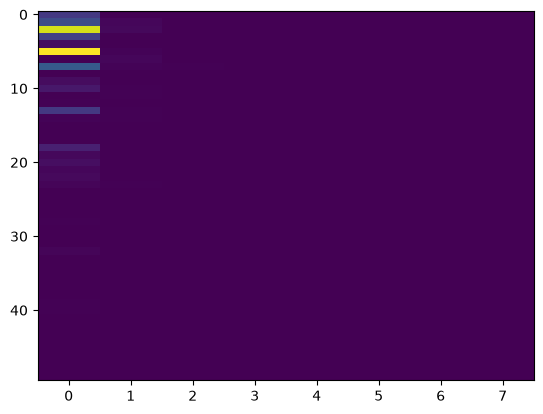

In [14]:

plt.imshow(np.asarray(chaos_psd)[:50, :8], aspect='auto')